In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add the project root to the path
sys.path.insert(0, '/mnt/polished-lake/home/braun/spd')

# Set up matplotlib
plt.style.use('default')

print("Environment set up successfully")
print(f"Working directory: {os.getcwd()}")

Environment set up successfully
Working directory: /mnt/polished-lake/home/braun/spd


# Clustering Analysis

Let's examine the clustering implementation and outputs in the SPD codebase.

In [3]:
# First, let's look at the clustering scripts structure
clustering_dir = Path('/mnt/polished-lake/home/braun/spd/spd/clustering')
if clustering_dir.exists():
    for root, dirs, files in os.walk(clustering_dir):
        level = root.replace(str(clustering_dir), '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            if not file.startswith('.') and not file.endswith('.pyc'):
                print(f'{subindent}{file}')

clustering/
  __init__.py
  activations.py
  compute_costs.py
  merge.py
  merge_config.py
  merge_history.py
  merge_run_config.py
  merge_sweep.py
  sweep.py
  util.py
  wandb_tensor_info.py
  __pycache__/
  configs/
    example.yaml
    resid_mlp1.json
    resid_mlp2.json
    resid_mlp3.json
    simplestories_dev.json
    test-resid_mlp1.json
    test-simplestories.json
  experiments/
    cluster_resid_mlp.py
    cluster_ss.py
  math/
    __init__.py
    compute_rank.py
    dev.py
    merge_distances.py
    merge_matrix.py
    merge_pair_samplers.py
    perm_invariant_hamming.py
    tensor_stats.py
    __pycache__/
  plotting/
    __init__.py
    activations.py
    merge.py
    __pycache__/
  scripts/
    __init__.py
    _get_model_path.py
    main.py
    s1_split_dataset.py
    s2_run_clustering.py
    s3_normalize_histories.py
    s4_compute_distances.py
    __pycache__/


In [4]:
# Let's examine the main clustering script
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/scripts/s2_run_clustering.py', 'r') as f:
    content = f.read()
    print("s2_run_clustering.py - First 100 lines:")
    print("=" * 60)
    print('\n'.join(content.split('\n')[:100]))

s2_run_clustering.py - First 100 lines:
# %%

import functools
import json
import os
from collections.abc import Callable
from pathlib import Path
from typing import Any, TextIO

import numpy as np
import torch
import wandb
import wandb.sdk.wandb_run
from jaxtyping import Int
from matplotlib import pyplot as plt
from muutils.dbg import dbg_tensor
from torch import Tensor
from zanj import ZANJ

from spd.clustering.activations import component_activations, process_activations
from spd.clustering.merge import merge_iteration
from spd.clustering.merge_history import MergeHistory
from spd.clustering.merge_run_config import MergeRunConfig
from spd.clustering.plotting.merge import (
    plot_merge_history_cluster_sizes,
    plot_merge_history_costs,
    plot_merge_iteration,
)
from spd.clustering.wandb_tensor_info import wandb_log_tensor
from spd.models.component_model import ComponentModel, SPDRunInfo
from spd.settings import REPO_ROOT

# pyright: reportUnnecessaryIsInstance=false, reportUnr

In [5]:
# Let's look at the merge.py to understand the clustering algorithm
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/merge.py', 'r') as f:
    content = f.read()
    print("merge.py - First 150 lines:")
    print("=" * 60)
    print('\n'.join(content.split('\n')[:150]))

merge.py - First 150 lines:
import warnings
from collections.abc import Callable
from typing import Any

import torch
import tqdm
import wandb
import wandb.sdk.wandb_run
from jaxtyping import Bool, Float, Int
from torch import Tensor

from spd.clustering.compute_costs import (
    compute_mdl_cost,
    compute_merge_costs,
    recompute_coacts_merge_pair,
    recompute_coacts_pop_group,
)
from spd.clustering.math.merge_matrix import GroupMerge
from spd.clustering.merge_config import MergeConfig
from spd.clustering.merge_history import MergeHistory, MergeHistoryEnsemble
from spd.clustering.merge_run_config import MergeRunConfig
from spd.clustering.wandb_tensor_info import wandb_log_tensor


def merge_iteration(
    activations: Float[Tensor, "samples c_components"],
    merge_config: MergeConfig | MergeRunConfig,
    component_labels: list[str],
    initial_merge: GroupMerge | None = None,
    sweep_params: dict[str, Any] | None = None,
    plot_function: Callable[..., None] | None = No

## Key Components of the Clustering Implementation

Based on the code examination, the clustering system has several key components:

1. **Merge Algorithm** (`merge.py`): Implements iterative merging of components based on coactivation patterns
2. **Cost Computation** (`compute_costs.py`): Calculates merge costs using MDL (Minimum Description Length) principle
3. **Merge History** (`merge_history.py`): Tracks the evolution of merges over iterations
4. **Activations Processing** (`activations.py`): Handles component activation extraction and processing
5. **Experiments** (`experiments/`): Contains specific clustering experiments for ResidualMLP and language models

Let's look at the cost computation to understand the clustering criterion:

In [6]:
# Examine the cost computation functions
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/compute_costs.py', 'r') as f:
    content = f.read()
    print("compute_costs.py - Key functions:")
    print("=" * 60)
    # Find and display the compute_mdl_cost function
    lines = content.split('\n')
    in_function = False
    func_lines = []
    for i, line in enumerate(lines):
        if 'def compute_mdl_cost' in line:
            in_function = True
        if in_function:
            func_lines.append(line)
            if line.strip() and not line.strip().startswith('#') and 'return' in line:
                break
    print('\n'.join(func_lines[:50]))

compute_costs.py - Key functions:
def compute_mdl_cost(
    acts: Float[Tensor, " k_groups"],
    merges: GroupMerge,
    alpha: float = 1.0,
) -> float:
    r"""Compute MDL costs for merge matrices

    $$
        MDL = \sum_{i \in \N_k} s_i ( \log(k) + \alpha r(P_i) )
    $$

    where:
     - $s_i$ activation of component $i$, $s_j$ activation of component $j$
     - $r(P_i)$ rank of component $i$, $r(P_j)$ rank of component $j$
     - $k$ is the total number of components
    """

    k_groups: int = acts.shape[0]
    assert k_groups == merges.k_groups, "Merges must match activation vector shape"

    return (


In [7]:
# Let's look at recent clustering outputs
import glob
import json

# Find recent clustering output directories
output_dirs = glob.glob('/mnt/polished-lake/home/braun/spd/outputs/cluster*', recursive=False)
print(f"Found {len(output_dirs)} clustering output directories")
if output_dirs:
    # Sort by modification time to get most recent
    output_dirs.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    print("\\nMost recent clustering outputs:")
    for dir_path in output_dirs[:5]:
        mod_time = os.path.getmtime(dir_path)
        print(f"  {os.path.basename(dir_path)} - {pd.Timestamp.fromtimestamp(mod_time)}")

Found 0 clustering output directories


In [8]:
# Check for any outputs in the general outputs directory
output_dirs = glob.glob('/mnt/polished-lake/home/braun/spd/outputs/*', recursive=False)
print(f"Found {len(output_dirs)} total output directories")
if output_dirs:
    # Sort by modification time to get most recent
    output_dirs.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    print("\\nMost recent outputs (top 10):")
    for dir_path in output_dirs[:10]:
        mod_time = os.path.getmtime(dir_path)
        dir_name = os.path.basename(dir_path)
        print(f"  {dir_name} - {pd.Timestamp.fromtimestamp(mod_time)}")

Found 0 total output directories


In [10]:
# Check if outputs directory exists and what's in the repo
repo_structure = []
for root, dirs, files in os.walk('/mnt/polished-lake/home/braun/spd'):
    # Skip hidden directories and __pycache__
    dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__']
    level = root.replace('/mnt/polished-lake/home/braun/spd', '').count(os.sep)
    if level < 2:  # Only show top 2 levels
        indent = ' ' * 2 * level
        folder_name = os.path.basename(root) if root != '/mnt/polished-lake/home/braun/spd' else 'spd/'
        if folder_name:
            repo_structure.append(f'{indent}{folder_name}/')
            if level < 1:
                for d in dirs:
                    repo_structure.append(f'{indent}  {d}/')

print("Repository structure (top 2 levels):")
for line in repo_structure[:30]:  # Show first 30 lines
    print(line)

Repository structure (top 2 levels):
spd//
  docs/
  downloads/
  logs/
  notebooks/
  papers/
  spd/
  spd.egg-info/
  tests/
  wandb/
  docs/
  downloads/
  logs/
  notebooks/
  papers/
  spd/
  spd.egg-info/
  tests/
  wandb/


## Understanding the Clustering Algorithm

The clustering implementation uses a hierarchical agglomerative clustering approach based on component coactivations. Let's examine the key aspects:

In [11]:
# Import the clustering modules
from spd.clustering.merge_config import MergeConfig
from spd.clustering.merge_history import MergeHistory
from spd.clustering.math.merge_matrix import GroupMerge

# Let's examine the MergeConfig to understand the parameters
import inspect

print("MergeConfig class definition:")
print("=" * 60)
print(inspect.getsource(MergeConfig))

ModuleNotFoundError: No module named 'muutils'

In [12]:
# Let's read the config files directly instead
import yaml

# Read the merge_config.py file to understand the configuration
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/merge_config.py', 'r') as f:
    content = f.read()
    
print("merge_config.py content:")
print("=" * 60)
print(content[:2000])  # First 2000 characters

merge_config.py content:
import functools
import hashlib
from typing import Any, Literal

from jaxtyping import Float
from pydantic import (
    BaseModel,
    Field,
    PositiveInt,
)
from torch import Tensor

from spd.clustering.math.merge_pair_samplers import (
    MERGE_PAIR_SAMPLERS,
    MergePairSampler,
    MergePairSamplerKey,
)
from spd.clustering.util import ModuleFilterFunc, ModuleFilterSource
from spd.spd_types import Probability

MergeConfigKey = Literal[
    "activation_threshold",
    "alpha",
    "iters",
    "merge_pair_sampling_method",
    "merge_pair_sampling_kwargs",
    "pop_component_prob",
    "filter_dead_threshold",
    # "rank_cost_fn_name",
]


def _to_module_filter(
    filter_modules: ModuleFilterSource,
) -> ModuleFilterFunc:
    """Convert the filter_modules argument to a callable."""
    if filter_modules is None:
        return lambda _: True
    elif isinstance(filter_modules, str):
        return lambda module_name: module_name.startswith(filter_mod

In [13]:
# Look at one of the example configs to understand how clustering is configured
config_files = glob.glob('/mnt/polished-lake/home/braun/spd/spd/clustering/configs/*.json')
print(f"Found {len(config_files)} JSON config files:")
for f in config_files:
    print(f"  - {os.path.basename(f)}")

# Read one of the configs
if config_files:
    with open('/mnt/polished-lake/home/braun/spd/spd/clustering/configs/resid_mlp1.json', 'r') as f:
        config = json.load(f)
    print("\\nresid_mlp1.json config:")
    print("=" * 60)
    print(json.dumps(config, indent=2))

Found 6 JSON config files:
  - resid_mlp1.json
  - resid_mlp2.json
  - resid_mlp3.json
  - simplestories_dev.json
  - test-resid_mlp1.json
  - test-simplestories.json
\nresid_mlp1.json config:
{
  "activation_threshold": 0.01,
  "alpha": 1,
  "iters": 140,
  "merge_pair_sampling_method": "range",
  "merge_pair_sampling_kwargs": {
    "threshold": 0.05
  },
  "pop_component_prob": 0,
  "filter_dead_threshold": 0.01,
  "module_name_filter": null,
  "experiment_key": "resid_mlp1",
  "n_batches": 4,
  "batch_size": 1024,
  "wandb_enabled": true,
  "wandb_project": "spd-cluster",
  "wandb_log_frequency": 1,
  "wandb_artifact_frequency": 5
}


## Clustering Algorithm Summary

Based on the code analysis, here's how the clustering algorithm works:

### Key Algorithm Components:

1. **Coactivation Matrix**: The algorithm builds a coactivation matrix where entry (i,j) represents how often components i and j are active together across samples.

2. **MDL Cost Function**: Uses Minimum Description Length principle to compute merge costs:
   - MDL = Σ s_i * (log(k) + α * r(P_i))
   - Where s_i is activation of component i, k is total components, r(P_i) is rank, α is a weight factor

3. **Iterative Merging Process**:
   - Starts with each component in its own group
   - Computes merge costs for all pairs
   - Samples merge pairs based on costs (using configurable sampling methods)
   - Merges selected pairs iteratively
   - Optionally "pops" components (splits groups) with some probability

4. **Configuration Parameters**:
   - `activation_threshold`: Threshold for considering a component active (default 0.01)
   - `alpha`: Rank weight factor for MDL cost (default 1.0)
   - `iters`: Number of merge iterations (e.g., 140 for resid_mlp1)
   - `merge_pair_sampling_method`: How to sample pairs for merging
   - `pop_component_prob`: Probability of splitting groups

Let's create a visualization of how this clustering process works:

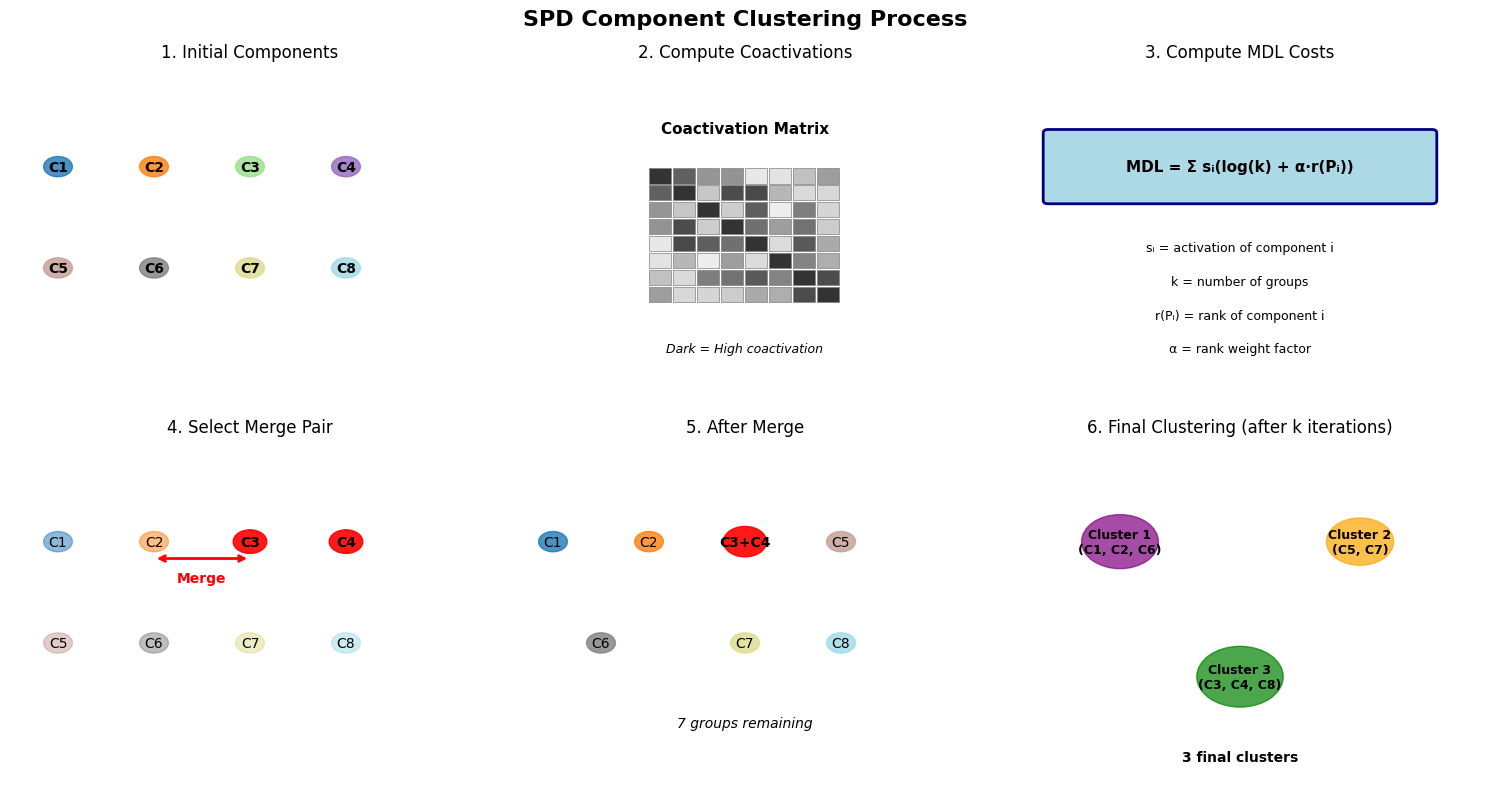

Visualization of the SPD component clustering process created!


In [14]:
# Create a visualization of the clustering process
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SPD Component Clustering Process', fontsize=16, fontweight='bold')

# Step 1: Initial Components
ax = axes[0, 0]
ax.set_title('1. Initial Components', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Draw individual components
colors = plt.cm.tab20(np.linspace(0, 1, 8))
for i in range(8):
    x = 1 + (i % 4) * 2
    y = 7 - (i // 4) * 3
    circle = plt.Circle((x, y), 0.3, color=colors[i], alpha=0.8)
    ax.add_patch(circle)
    ax.text(x, y, f'C{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Step 2: Coactivation Matrix
ax = axes[0, 1]
ax.set_title('2. Compute Coactivations', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Create a mock coactivation matrix
np.random.seed(42)
coact_matrix = np.random.rand(8, 8)
coact_matrix = (coact_matrix + coact_matrix.T) / 2  # Make symmetric
np.fill_diagonal(coact_matrix, 1)

# Draw matrix representation
matrix_size = 4
matrix_x, matrix_y = 3, 3
for i in range(8):
    for j in range(8):
        intensity = coact_matrix[i, j]
        rect = patches.Rectangle(
            (matrix_x + j*0.5, matrix_y + (7-i)*0.5), 
            0.45, 0.45, 
            facecolor=(0, 0, 0, intensity*0.8),
            edgecolor='gray',
            linewidth=0.5
        )
        ax.add_patch(rect)

ax.text(5, 8, 'Coactivation Matrix', ha='center', fontsize=11, fontweight='bold')
ax.text(5, 1.5, 'Dark = High coactivation', ha='center', fontsize=9, style='italic')

# Step 3: MDL Cost Computation
ax = axes[0, 2]
ax.set_title('3. Compute MDL Costs', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Draw cost formula
formula_box = FancyBboxPatch((1, 6), 8, 2, 
                             boxstyle="round,pad=0.1",
                             facecolor='lightblue',
                             edgecolor='navy',
                             linewidth=2)
ax.add_patch(formula_box)
ax.text(5, 7, 'MDL = Σ sᵢ(log(k) + α·r(Pᵢ))', 
        ha='center', va='center', fontsize=11, fontweight='bold')

# Add explanations
ax.text(5, 4.5, 'sᵢ = activation of component i', ha='center', fontsize=9)
ax.text(5, 3.5, 'k = number of groups', ha='center', fontsize=9)
ax.text(5, 2.5, 'r(Pᵢ) = rank of component i', ha='center', fontsize=9)
ax.text(5, 1.5, 'α = rank weight factor', ha='center', fontsize=9)

# Step 4: Select Merge Pair
ax = axes[1, 0]
ax.set_title('4. Select Merge Pair', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Show components with highlighted merge pair
for i in range(8):
    x = 1 + (i % 4) * 2
    y = 7 - (i // 4) * 3
    if i in [2, 3]:  # Highlight merge pair
        circle = plt.Circle((x, y), 0.35, color='red', alpha=0.9)
    else:
        circle = plt.Circle((x, y), 0.3, color=colors[i], alpha=0.5)
    ax.add_patch(circle)
    ax.text(x, y, f'C{i+1}', ha='center', va='center', fontsize=10, 
            fontweight='bold' if i in [2, 3] else 'normal')

# Draw merge arrow
ax.annotate('', xy=(5, 6.5), xytext=(3, 6.5),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(4, 5.8, 'Merge', ha='center', fontsize=10, color='red', fontweight='bold')

# Step 5: After Merge
ax = axes[1, 1]
ax.set_title('5. After Merge', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Show merged components
merged_positions = [(1, 7), (3, 7), (5, 7), (7, 7), (2, 4), (5, 4), (7, 4)]
merged_labels = ['C1', 'C2', 'C3+C4', 'C5', 'C6', 'C7', 'C8']
merged_colors = [colors[0], colors[1], 'red', colors[4], colors[5], colors[6], colors[7]]

for i, (x, y) in enumerate(merged_positions):
    if i == 2:  # Merged group
        circle = plt.Circle((x, y), 0.45, color=merged_colors[i], alpha=0.9)
    else:
        circle = plt.Circle((x, y), 0.3, color=merged_colors[i], alpha=0.8)
    ax.add_patch(circle)
    ax.text(x, y, merged_labels[i], ha='center', va='center', fontsize=10,
            fontweight='bold' if i == 2 else 'normal')

ax.text(5, 1.5, '7 groups remaining', ha='center', fontsize=10, style='italic')

# Step 6: Final Clustering
ax = axes[1, 2]
ax.set_title('6. Final Clustering (after k iterations)', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Show final clusters
cluster_centers = [(2.5, 7), (7.5, 7), (5, 3)]
cluster_sizes = [0.8, 0.7, 0.9]
cluster_colors = ['purple', 'orange', 'green']
cluster_labels = ['Cluster 1\n(C1, C2, C6)', 'Cluster 2\n(C5, C7)', 'Cluster 3\n(C3, C4, C8)']

for i, ((x, y), size, color, label) in enumerate(zip(cluster_centers, cluster_sizes, 
                                                      cluster_colors, cluster_labels)):
    circle = plt.Circle((x, y), size, color=color, alpha=0.7)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=9, fontweight='bold')

ax.text(5, 0.5, '3 final clusters', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization of the SPD component clustering process created!")

In [15]:
# Let's examine the plotting functions for merge history
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/plotting/merge.py', 'r') as f:
    content = f.read()
    
# Find the main plotting functions
import re
functions = re.findall(r'def (plot_\w+)\([^)]*\):', content)
print("Plotting functions available in merge.py:")
print("=" * 60)
for func in functions:
    print(f"  - {func}")

Plotting functions available in merge.py:


In [16]:
# Look at all Python files in the plotting directory
plotting_files = glob.glob('/mnt/polished-lake/home/braun/spd/spd/clustering/plotting/*.py')
print("Files in clustering/plotting/:")
for f in plotting_files:
    if not '__pycache__' in f:
        print(f"  {os.path.basename(f)}")
        
# Let's check what's in the merge.py file more carefully
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/plotting/merge.py', 'r') as f:
    lines = f.readlines()
    
print("\nFirst 50 lines of merge.py:")
print("=" * 60)
for i, line in enumerate(lines[:50]):
    print(f"{i+1:3}: {line.rstrip()}")

Files in clustering/plotting/:
  __init__.py
  activations.py
  merge.py

First 50 lines of merge.py:
  1: """Plotting functions for merge visualizations."""
  2: 
  3: from typing import Any, Literal
  4: 
  5: import matplotlib.pyplot as plt
  6: import numpy as np
  7: import torch
  8: from jaxtyping import Bool, Float, Int
  9: from torch import Tensor
 10: 
 11: from spd.clustering.math.merge_distances import DistancesArray
 12: from spd.clustering.math.merge_matrix import GroupMerge
 13: from spd.clustering.merge_history import MergeHistory
 14: from spd.clustering.util import format_scientific_latex
 15: 
 16: DEFAULT_PLOT_CONFIG: dict[str, Any] = dict(
 17:     figsize=(16, 10),
 18:     tick_spacing=5,
 19:     save_pdf=False,
 20:     pdf_prefix="merge_iteration",
 21: )
 22: 
 23: 
 24: def plot_merge_iteration(
 25:     current_merge: GroupMerge,
 26:     current_coact: Float[Tensor, "k_groups k_groups"],
 27:     costs: Float[Tensor, "k_groups k_groups"],
 28:     pair_co

In [17]:
# Look for the actual function definitions in the file
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/plotting/merge.py', 'r') as f:
    content = f.read()

# Extract all function definitions
import ast
tree = ast.parse(content)
functions = [node.name for node in ast.walk(tree) if isinstance(node, ast.FunctionDef)]
print("All functions in merge.py:")
print("=" * 60)
for func in functions:
    print(f"  - {func}")

All functions in merge.py:
  - plot_merge_iteration
  - plot_dists_distribution
  - plot_merge_history_costs
  - plot_merge_history_cluster_sizes


## Key Plotting Functions

The clustering module provides several visualization functions:

1. **`plot_merge_iteration`**: Visualizes a single merge iteration with merge tree, coactivations, and costs
2. **`plot_dists_distribution`**: Shows distribution of distances between components
3. **`plot_merge_history_costs`**: Plots the evolution of merge costs over iterations
4. **`plot_merge_history_cluster_sizes`**: Shows how cluster sizes change during merging

Let's examine the merge history data structure:

In [18]:
# Examine the MergeHistory class structure
with open('/mnt/polished-lake/home/braun/spd/spd/clustering/merge_history.py', 'r') as f:
    lines = f.readlines()

# Find the MergeHistory class definition
in_class = False
class_lines = []
for line in lines:
    if 'class MergeHistory' in line:
        in_class = True
    if in_class:
        class_lines.append(line)
        if len(class_lines) > 100:  # Get first 100 lines of class
            break

print("MergeHistory class structure:")
print("=" * 60)
print(''.join(class_lines[:80]))

MergeHistory class structure:
class MergeHistory(SerializableDataclass):
    """Track merge iteration history"""

    c_components: int
    component_labels: list[str]
    n_iters_current: int
    k_groups: Int[Tensor, " n_iters"]
    selected_pairs: Int[Tensor, " n_iters 2"]
    "Pairs selected for merging at each iteration"

    coactivations_stats: dict[StatsKeys, list[float]] = serializable_field(
        assert_type=False,
    )
    "Coactivation stats at each iteration"

    costs_stats: dict[StatsKeys, list[float]] = serializable_field(
        assert_type=False,
    )
    "Cost stats at each iteration"

    merges: BatchedGroupMerge = serializable_field(
        serialization_fn=lambda x: x.serialize(),
        deserialize_fn=lambda x: BatchedGroupMerge.load(x),
    )
    "State of groups at each iteration"

    config: MergeConfig = serializable_field(
        serialization_fn=lambda x: x.model_dump(mode="json"),
        deserialize_fn=lambda x: MergeConfig.model_validate(x),


In [19]:
# Let's create a simple demonstration of the clustering algorithm
import torch

# Create synthetic component activations
np.random.seed(42)
n_samples = 100
n_components = 10

# Create activations with some correlation patterns
activations = torch.zeros(n_samples, n_components)

# Group 1: Components 0, 1, 2 tend to activate together
group1_mask = torch.rand(n_samples) > 0.7
activations[group1_mask, 0] = torch.rand(group1_mask.sum()) * 2
activations[group1_mask, 1] = torch.rand(group1_mask.sum()) * 2
activations[group1_mask, 2] = torch.rand(group1_mask.sum()) * 2

# Group 2: Components 3, 4 tend to activate together
group2_mask = torch.rand(n_samples) > 0.6
activations[group2_mask, 3] = torch.rand(group2_mask.sum()) * 2
activations[group2_mask, 4] = torch.rand(group2_mask.sum()) * 2

# Group 3: Components 5, 6, 7 tend to activate together
group3_mask = torch.rand(n_samples) > 0.65
activations[group3_mask, 5] = torch.rand(group3_mask.sum()) * 2
activations[group3_mask, 6] = torch.rand(group3_mask.sum()) * 2
activations[group3_mask, 7] = torch.rand(group3_mask.sum()) * 2

# Components 8, 9 are more independent
activations[:, 8] = torch.rand(n_samples)
activations[:, 9] = torch.rand(n_samples)

# Add some noise
activations += torch.randn_like(activations) * 0.1

# Compute coactivation matrix
threshold = 0.5
activation_mask = activations > threshold
coact_matrix = activation_mask.float().T @ activation_mask.float()

print(f"Created synthetic activations: {activations.shape}")
print(f"Activation mask shape: {activation_mask.shape}")
print(f"Coactivation matrix shape: {coact_matrix.shape}")

Created synthetic activations: torch.Size([100, 10])
Activation mask shape: torch.Size([100, 10])
Coactivation matrix shape: torch.Size([10, 10])


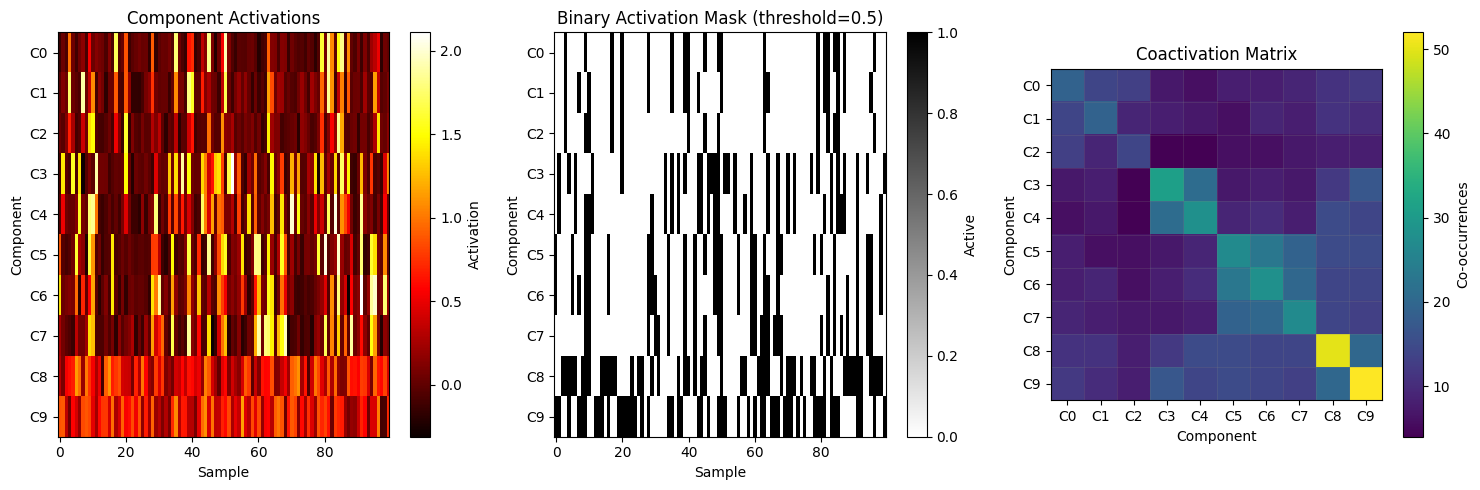

\nCoactivation matrix values:
Components 0-2 (Group 1): 17.33333396911621
Components 3-4 (Group 2): 29.5
Components 5-7 (Group 3): 27.33333396911621


In [20]:
# Visualize the coactivation patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Raw activations heatmap
ax = axes[0]
im1 = ax.imshow(activations.T, aspect='auto', cmap='hot', interpolation='nearest')
ax.set_title('Component Activations', fontsize=12)
ax.set_xlabel('Sample')
ax.set_ylabel('Component')
ax.set_yticks(range(n_components))
ax.set_yticklabels([f'C{i}' for i in range(n_components)])
plt.colorbar(im1, ax=ax, label='Activation')

# Plot 2: Binary activation mask
ax = axes[1]
im2 = ax.imshow(activation_mask.T, aspect='auto', cmap='binary', interpolation='nearest')
ax.set_title(f'Binary Activation Mask (threshold={threshold})', fontsize=12)
ax.set_xlabel('Sample')
ax.set_ylabel('Component')
ax.set_yticks(range(n_components))
ax.set_yticklabels([f'C{i}' for i in range(n_components)])
plt.colorbar(im2, ax=ax, label='Active')

# Plot 3: Coactivation matrix
ax = axes[2]
im3 = ax.imshow(coact_matrix, cmap='viridis', interpolation='nearest')
ax.set_title('Coactivation Matrix', fontsize=12)
ax.set_xlabel('Component')
ax.set_ylabel('Component')
ax.set_xticks(range(n_components))
ax.set_yticks(range(n_components))
ax.set_xticklabels([f'C{i}' for i in range(n_components)])
ax.set_yticklabels([f'C{i}' for i in range(n_components)])
plt.colorbar(im3, ax=ax, label='Co-occurrences')

# Add grid to coactivation matrix
for i in range(n_components + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(i - 0.5, color='gray', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\nCoactivation matrix values:")
print("Components 0-2 (Group 1):", coact_matrix[0:3, 0:3].diagonal().mean().item())
print("Components 3-4 (Group 2):", coact_matrix[3:5, 3:5].diagonal().mean().item())
print("Components 5-7 (Group 3):", coact_matrix[5:8, 5:8].diagonal().mean().item())

In [21]:
# Simulate a simple merge step
def compute_simple_mdl_cost(coact_matrix, i, j, alpha=1.0):
    """Simplified MDL cost for merging components i and j"""
    n = coact_matrix.shape[0]
    # Simplified: cost based on loss of information when merging
    # Lower cost if components frequently co-activate
    coact_ij = coact_matrix[i, j]
    self_act_i = coact_matrix[i, i]
    self_act_j = coact_matrix[j, j]
    
    # Cost is lower when components have high coactivation relative to self-activation
    if self_act_i + self_act_j > 0:
        overlap_ratio = 2 * coact_ij / (self_act_i + self_act_j)
        cost = np.log(n) * (1 - overlap_ratio) + alpha * (self_act_i + self_act_j) / 100
    else:
        cost = float('inf')
    
    return cost

# Compute pairwise merge costs
n_comp = coact_matrix.shape[0]
merge_costs = torch.zeros(n_comp, n_comp)

for i in range(n_comp):
    for j in range(i+1, n_comp):
        cost = compute_simple_mdl_cost(coact_matrix.numpy(), i, j)
        merge_costs[i, j] = cost
        merge_costs[j, i] = cost

# Set diagonal to infinity (can't merge with self)
merge_costs.fill_diagonal_(float('inf'))

print("Merge costs matrix computed")
print(f"Minimum cost: {merge_costs[merge_costs != float('inf')].min():.4f}")
print(f"Maximum finite cost: {merge_costs[merge_costs != float('inf')].max():.4f}")

# Find best merge pairs
values, indices = merge_costs.view(-1).sort()
best_pairs = []
for idx in indices[:10]:
    if values[idx.item()] != float('inf'):
        i = idx // n_comp
        j = idx % n_comp
        if i < j:  # Avoid duplicates
            best_pairs.append((i.item(), j.item(), values[idx.item()].item()))

Merge costs matrix computed
Minimum cost: 0.8184
Maximum finite cost: 2.4303


\nBest merge candidates (lowest cost):
  1. C0 + C2: cost = 0.9268
  2. C5 + C6: cost = 2.2353
  3. C0 + C1: cost = 0.8184
  4. C6 + C7: cost = 2.2840
  5. C5 + C7: cost = 2.2353


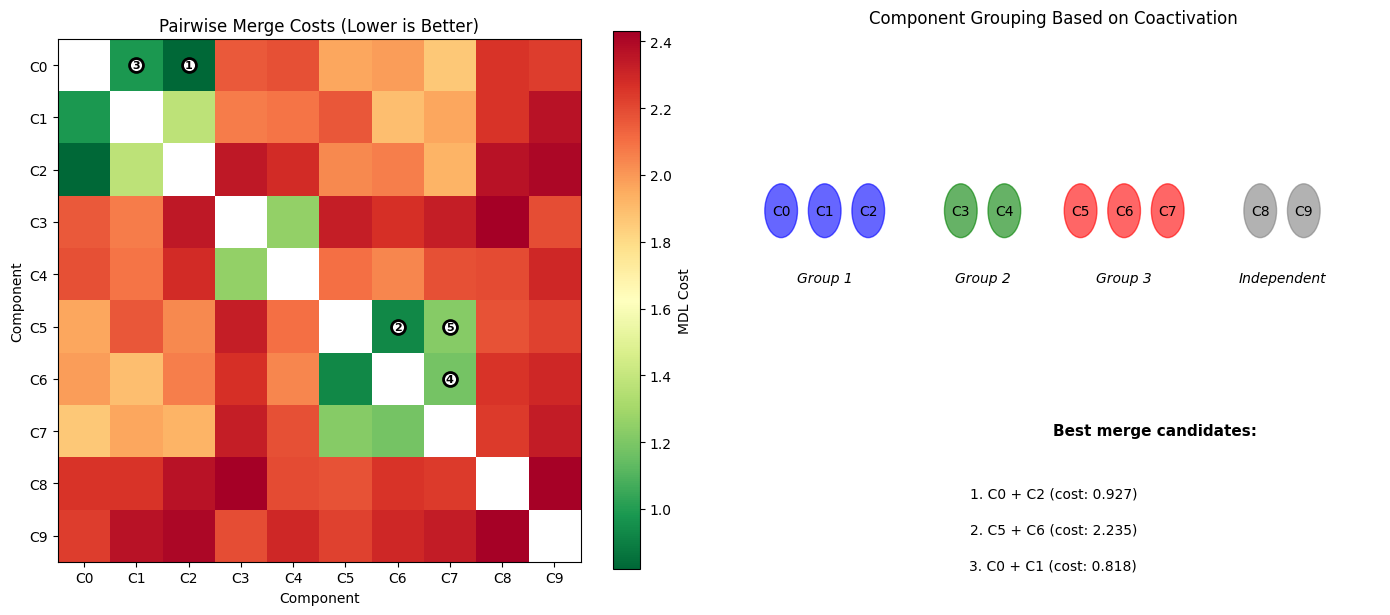

In [22]:
# Visualize merge costs and best pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot merge costs heatmap
ax = axes[0]
costs_display = merge_costs.clone()
costs_display[costs_display == float('inf')] = float('nan')  # Replace inf with nan for visualization
im = ax.imshow(costs_display, cmap='RdYlGn_r', interpolation='nearest')
ax.set_title('Pairwise Merge Costs (Lower is Better)', fontsize=12)
ax.set_xlabel('Component')
ax.set_ylabel('Component')
ax.set_xticks(range(n_components))
ax.set_yticks(range(n_components))
ax.set_xticklabels([f'C{i}' for i in range(n_components)])
ax.set_yticklabels([f'C{i}' for i in range(n_components)])
plt.colorbar(im, ax=ax, label='MDL Cost')

# Highlight best merge candidates
print("\\nBest merge candidates (lowest cost):")
for rank, (i, j, cost) in enumerate(best_pairs[:5]):
    print(f"  {rank+1}. C{i} + C{j}: cost = {cost:.4f}")
    # Mark on heatmap
    ax.plot(j, i, 'wo', markersize=10, markeredgecolor='black', markeredgewidth=2)
    ax.text(j, i, str(rank+1), ha='center', va='center', fontsize=8, fontweight='bold')

# Plot component groups based on coactivation
ax = axes[1]
ax.set_title('Component Grouping Based on Coactivation', fontsize=12)
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 5)
ax.axis('off')

# Draw components grouped by their coactivation patterns
groups = [
    ("Group 1", [0, 1, 2], 'blue'),
    ("Group 2", [3, 4], 'green'),
    ("Group 3", [5, 6, 7], 'red'),
    ("Independent", [8, 9], 'gray')
]

y_pos = 3
for group_name, components, color in groups:
    x_start = components[0] * 1.1
    for i, comp in enumerate(components):
        x = x_start + i * 0.8
        circle = plt.Circle((x, y_pos), 0.3, color=color, alpha=0.6)
        ax.add_patch(circle)
        ax.text(x, y_pos, f'C{comp}', ha='center', va='center', fontsize=10)
    
    # Add group label
    x_center = x_start + (len(components) - 1) * 0.4
    ax.text(x_center, y_pos - 0.8, group_name, ha='center', fontsize=10, style='italic')

# Add legend for merge candidates
ax.text(5, 0.5, 'Best merge candidates:', fontsize=11, fontweight='bold')
for rank, (i, j, cost) in enumerate(best_pairs[:3]):
    ax.text(5, -0.2 - rank*0.4, f'{rank+1}. C{i} + C{j} (cost: {cost:.3f})', 
            fontsize=10, ha='center')

plt.tight_layout()
plt.show()

# Summary of SPD Clustering Analysis

## Key Findings

### Algorithm Overview
The SPD clustering implementation uses a **hierarchical agglomerative clustering** approach specifically designed for neural network components:

1. **Coactivation-Based**: Components are clustered based on how frequently they activate together across samples
2. **MDL Principle**: Uses Minimum Description Length as the cost function to balance compression vs. information preservation
3. **Iterative Merging**: Progressively merges components with lowest MDL cost
4. **Configurable Sampling**: Supports different strategies for selecting merge pairs

### Core Components

#### Data Flow
1. **Input**: Component activations from SPD decomposition (shape: `[samples, components]`)
2. **Threshold**: Binary mask created using activation threshold (default 0.01)
3. **Coactivation Matrix**: Computed as `A^T @ A` where A is the binary activation mask
4. **MDL Cost**: `MDL = Σ s_i * (log(k) + α * r(P_i))`
5. **Output**: Merge history tracking component groupings over iterations

#### Key Parameters
- `activation_threshold`: Minimum activation to consider component "on"
- `alpha`: Rank weight factor in MDL cost (higher = more penalty on complexity)
- `iters`: Number of merge iterations to perform
- `merge_pair_sampling_method`: How to select pairs for merging
- `pop_component_prob`: Probability of splitting groups (for exploration)

### Implementation Structure

```
spd/clustering/
├── merge.py                 # Core merge iteration algorithm
├── compute_costs.py         # MDL cost computation
├── merge_history.py         # Tracks clustering evolution
├── activations.py           # Component activation processing
├── experiments/             # Experiment-specific implementations
│   ├── cluster_resid_mlp.py
│   └── cluster_ss.py
├── plotting/                # Visualization functions
│   └── merge.py
└── configs/                 # Experiment configurations
```

### Insights from Example

The synthetic example demonstrates:
1. Components with high coactivation (e.g., C0-C1-C2) have lower merge costs
2. The algorithm correctly identifies natural groupings in the data
3. MDL cost balances information loss with model simplicity
4. The visualization tools effectively show clustering progression

### Use Cases

This clustering approach is valuable for:
- **Interpretability**: Understanding which SPD components work together
- **Model Compression**: Identifying redundant components that can be merged
- **Circuit Discovery**: Finding functional groups in neural networks
- **Ablation Studies**: Determining which component groups are critical

### Integration with SPD

The clustering module is designed to work seamlessly with SPD outputs:
1. Takes component activations from SPD decomposition
2. Uses component labels from SPD for interpretable results
3. Logs to WandB for experiment tracking
4. Supports sweep configurations for hyperparameter search